# Домашная работа №4

Датасет был взять c kaggle: https://www.kaggle.com/datasets/zabihullah18/students-social-network-profile-clustering


Датасет содержит информацию о профилях старшеклассников в социальных сетях со следующими характеристиками:

#### Демографические данные
- **gradyear** - Год выпуска из школы
- **gender** - Пол ученика (мужской/женский)
- **age** - Возраст на момент опроса

#### Социальная активность
- **NumberOffriends** - Количество друзей/контактов в соцсети

#### Спортивные интересы
- **basketball** - Упоминания баскетбола
- **football** - Упоминания американского футбола
- **soccer** - Упоминания футбола (соккера)
- **softball** - Упоминания софтбола
- **volleyball** - Упоминания волейбола
- **swimming** - Упоминания плавания
- **cheerleading** - Упоминания чирлидинга
- **baseball** - Упоминания бейсбола
- **tennis** - Упоминания тенниса
- **sports** - Общие упоминания спорта

#### Музыкальные предпочтения
- **rock** - Упоминания рок-музыки
- **band** - Упоминания музыкальных групп
- **marching** - Упоминания марширования
- **music** - Упоминания музыки
- **dance** - Упоминания танцев

#### Религиозные темы
- **god** - Упоминания Бога
- **church** - Упоминания церкви
- **jesus** - Упоминания Иисуса
- **bible** - Упоминания Библии

#### Темы связанные шопингом
- **dress** - Упоминания одежды (платьев)
- **clothes** - Упоминания одежды
- **hollister** - Упоминания бренда Hollister
- **abercrombie** - Упоминания бренда Abercrombie
- **mall** - Упоминания торговых центров
- **shopping** - Упоминания шопинга

#### Отношения
- **sex** - Упоминания секса
- **sexy** - Упоминания "сексуальный"
- **hot** - Упоминания "горячий"
- **kissed** - Упоминания поцелуев

#### Внешний вид
- **cute** - Упоминания "милый"
- **hair** - Упоминания причёски
- **blonde** - Упоминания блондинов/блондинок
- **dress** - Упоминания одежды (платьев)
- **clothes** - Упоминания одежды

#### Девиантные темы
- **die** - Упоминания смерти (глагол)
- **death** - Упоминания смерти
- **drunk** - Упоминания алкогольного опьянения
- **drugs** - Упоминания наркотиков

> Примечание: Все показатели измеряются частотой упоминаний в профиле ученика.

### Набор признаков для кластерного анализа
**Спорт**, **Музыка**, **Религия**, **Мода**, **Внешний вид**, **Девиантные темы** - они будут вычисляться как сумма показателей полей слов из этой категории.

Также будем использовать косинусовое расстояния для расстояние между объектами. 

## Обработка данных

In [144]:
import pandas as pd
import numpy as np

In [145]:
data = pd.read_csv("03_Clustering_Marketing.csv")

data.head()
print("Пропущенные значения:\n", data.isnull().sum())

Пропущенные значения:
 gradyear              0
gender             1337
age                2496
NumberOffriends       0
basketball            0
football              0
soccer                0
softball              0
volleyball            0
swimming              0
cheerleading          0
baseball              0
tennis                0
sports                0
cute                  0
sex                   0
sexy                  0
hot                   0
kissed                0
dance                 0
band                  0
marching              0
music                 0
rock                  0
god                   0
church                0
jesus                 0
bible                 0
hair                  0
dress                 0
blonde                0
mall                  0
shopping              0
clothes               0
hollister             0
abercrombie           0
die                   0
death                 0
drunk                 0
drugs                 0
dtype: int64


In [146]:
df_new = pd.DataFrame()
# Группы столбцов
sports_cols = ['basketball', 'football', 'soccer', 'softball', 'volleyball', 'swimming', 'cheerleading', 'baseball', 'tennis', 'sports']
appearance_cols = ['cute', 'blonde', 'dress', 'clothes', 'hair']
relationships_cols = ['sex', 'sexy', 'hot', 'kissed']
music_cols = ['dance', 'band', 'marching', 'music', 'rock']
religion_cols = ['god', 'church', 'jesus', 'bible']
fashion_cols = ['dress', 'mall', 'shopping', 'clothes', 'hollister', 'abercrombie']
dark_cols = ['die', 'death', 'drunk', 'drugs']

# Суммируем значения по темам
df_new['sports_sum'] = data[sports_cols].sum(axis=1)
df_new['appearance_sum'] = data[appearance_cols].sum(axis=1)
df_new['relationships_sum'] = data[relationships_cols].sum(axis=1)
df_new['music_sum'] = data[music_cols].sum(axis=1)
df_new['religion_sum'] = data[religion_cols].sum(axis=1)
df_new['fashion_sum'] = data[fashion_cols].sum(axis=1)
df_new['dark_sum'] = data[dark_cols].sum(axis=1)
df_new = df_new.dropna()
df_new

,sports_sum,appearance_sum,relationships_sum,music_sum,religion_sum,fashion_sum,dark_sum
0,0,0,0,0,0,0,0
1,2,0,0,0,1,0,1
2,1,4,3,3,1,1,2
3,0,0,0,0,0,0,0
4,4,14,2,1,2,3,0
...,...,...,...,...,...,...,...
14995,0,3,0,1,1,2,1
14996,1,0,0,1,2,0,1
14997,1,1,0,0,0,0,0
14998,0,0,0,1,0,0,0


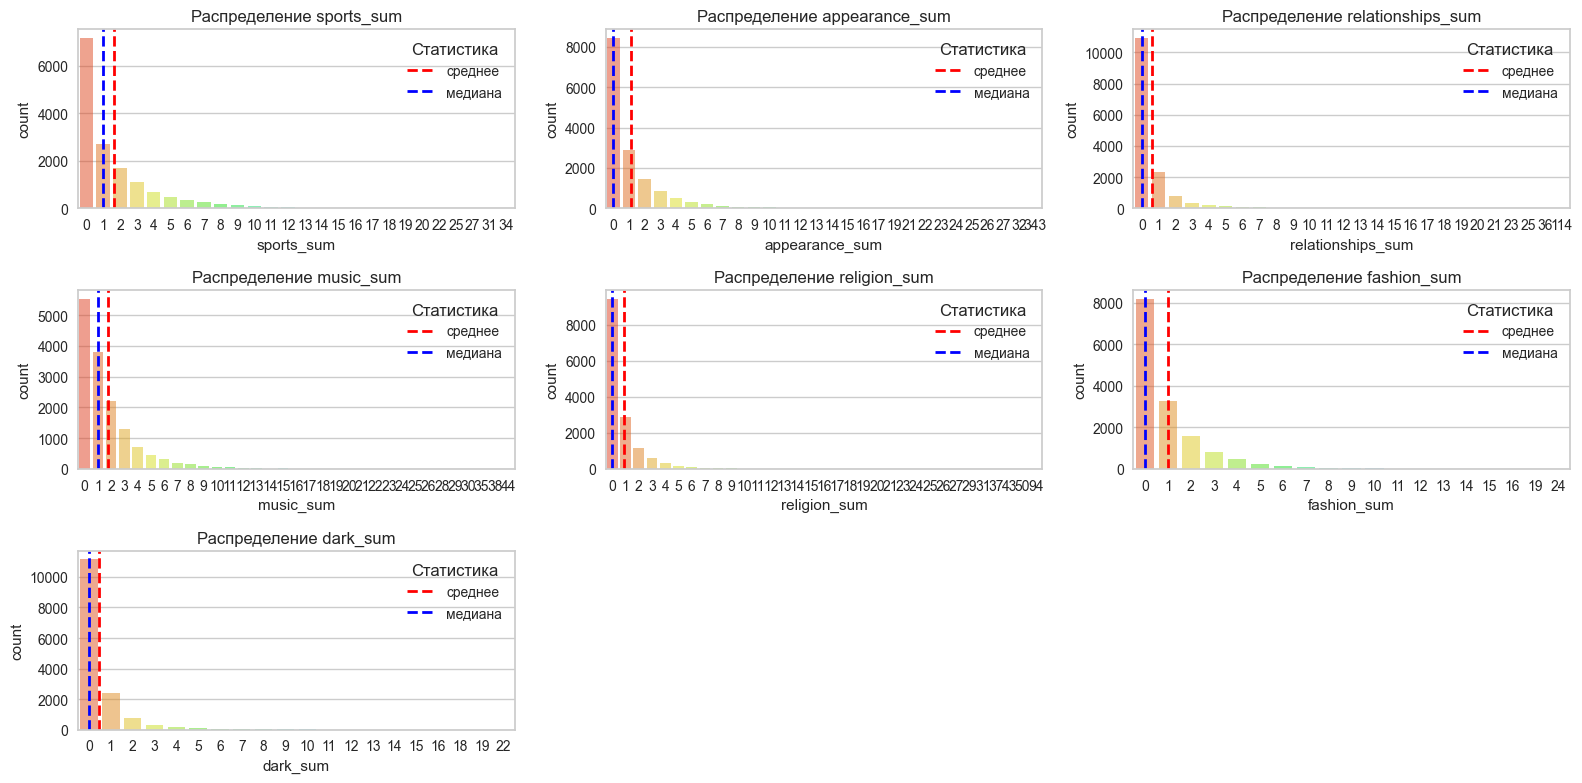

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
for i, col in enumerate(df_new.columns):
    plt.subplot(3, 3, i+1)
    if df_new[col].nunique() < 100:
        sns.countplot(x=col, data=df_new, palette='hsv', alpha=0.5)
    else:
        sns.kdeplot(df_new[col], fill=True, alpha=0.5)
    plt.title(f'Распределение {col}')
    
    plt.axvline(df_new[col].mean(), color='red', linestyle='dashed', linewidth=2, label='среднее')
    plt.axvline(df_new[col].median(), color='blue', linestyle='dashed', linewidth=2, label='медиана')
    plt.legend(loc='upper right', title='Статистика')
plt.tight_layout()
plt.show()

Уберем данные, где все нули, они не информативны и будут мешать при анализе в косинусовом расстоянии расстояние между такими объектам будет 1.

In [ ]:
mask_zero = (df_new.sum(axis=1) == 0)
df_new = df_new[~mask_zero]

df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13762 entries, 1 to 14999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   sports_sum         13762 non-null  int64
 1   appearance_sum     13762 non-null  int64
 2   relationships_sum  13762 non-null  int64
 3   music_sum          13762 non-null  int64
 4   religion_sum       13762 non-null  int64
 5   fashion_sum        13762 non-null  int64
 6   dark_sum           13762 non-null  int64
dtypes: int64(7)
memory usage: 860.1 KB


нормализуем данные

In [ ]:
from sklearn.preprocessing import MinMaxScaler
df_norm = df_new.copy()
    

upper_bounds = df_norm.quantile(0.95)

# Обрезаем выбросы в каждом столбце
for col in df_norm.columns:
    df_norm[col] = df_norm[col].clip(lower=0, upper=upper_bounds[col])

# Инициализируем и применяем MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 5))
scaled_values = scaler.fit_transform(df_norm)

# Создаем новый DataFrame с нормализованными значениями
df_new = pd.DataFrame(scaled_values, columns=df_new.columns, index=df_new.index)

убераем дублированные данные, которые могут помешать кластеризации.

In [150]:
df_new = df_new.drop_duplicates()
X = df_new.copy()

X_norm = df_new.copy()
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5979 entries, 1 to 14999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sports_sum         5979 non-null   float64
 1   appearance_sum     5979 non-null   float64
 2   relationships_sum  5979 non-null   float64
 3   music_sum          5979 non-null   float64
 4   religion_sum       5979 non-null   float64
 5   fashion_sum        5979 non-null   float64
 6   dark_sum           5979 non-null   float64
dtypes: float64(7)
memory usage: 373.7 KB


In [151]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from itertools import product

import plotly as py
import plotly.graph_objs as go

from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, OPTICS, estimate_bandwidth, MeanShift, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

import setuptools.dist
from yellowbrick.cluster import KElbowVisualizer

import warnings
warnings.filterwarnings('ignore')

## K-means

In [152]:
kmeans_params = {
    'init': 'k-means++',
    'n_init': 10,
    'max_iter': 300, 
    'tol': 0.0001,
    'random_state': 42,
    'algorithm': 'elkan',
}

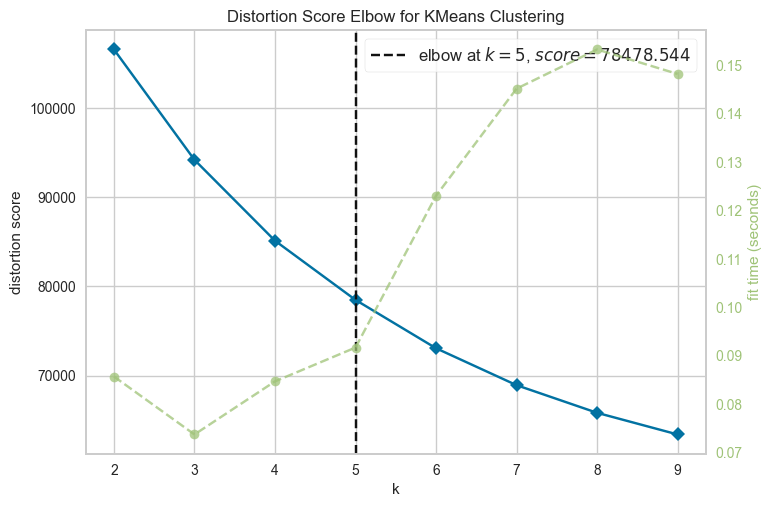

In [153]:
model = KMeans(**kmeans_params)
visualizer = KElbowVisualizer(model, k=(2,10))

visualizer.fit(X_norm)
visualizer.show()
plt.show()

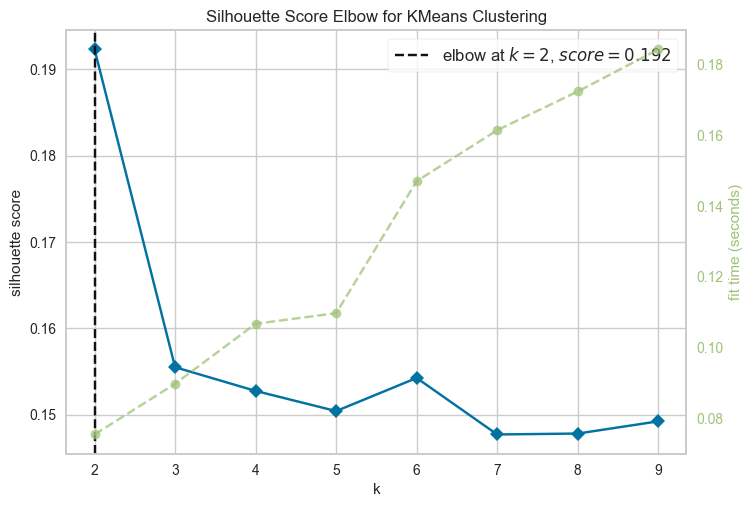

In [154]:
model = KMeans(**kmeans_params)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette')

visualizer.fit(X_norm)
visualizer.show()
plt.show()

In [226]:
N_CLUSTERS = 3

In [227]:
algorithm = KMeans(n_clusters = N_CLUSTERS, **kmeans_params)
algorithm.fit(X_norm)
labels3 = algorithm.labels_
centroids3 = algorithm.cluster_centers_

y_kmeans = algorithm.fit_predict(X_norm)
df_new['cluster_kmeans'] = y_kmeans
df_new.groupby('cluster_kmeans').size()

cluster_kmeans
0    2942
1    1225
2    1812
dtype: int64

## DBSCAN

In [164]:
# диапазон для поиска eps
eps_values = np.arange(0.01, 0.04, 0.005)
# диапазон для поиска min_samples
min_samples = np.arange(3, 10)

DBSCAN_params = list(product(eps_values, min_samples))

In [165]:
from sklearn.metrics import silhouette_score

num_clusters = []
num_outliers = []
sil_score = []

for eps, min_samples in DBSCAN_params:
    DBS_clustering = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine').fit(X)
    n_clusters = len(np.unique(DBS_clustering.labels_[DBS_clustering.labels_>=0]))
    num_clusters.append(n_clusters)
    num_outliers.append((DBS_clustering.labels_==-1).astype(int).sum())
    if n_clusters < 2:
        sil_score.append(-1)
    else:
        sil_score.append(silhouette_score(X, DBS_clustering.labels_, metric='cosine'))

tmp = pd.DataFrame.from_records(DBSCAN_params, columns =['Eps', 'Min_samples'])   
tmp['num_clusters'] = num_clusters
tmp['num_outliers'] = num_outliers
tmp['sil_score'] = sil_score


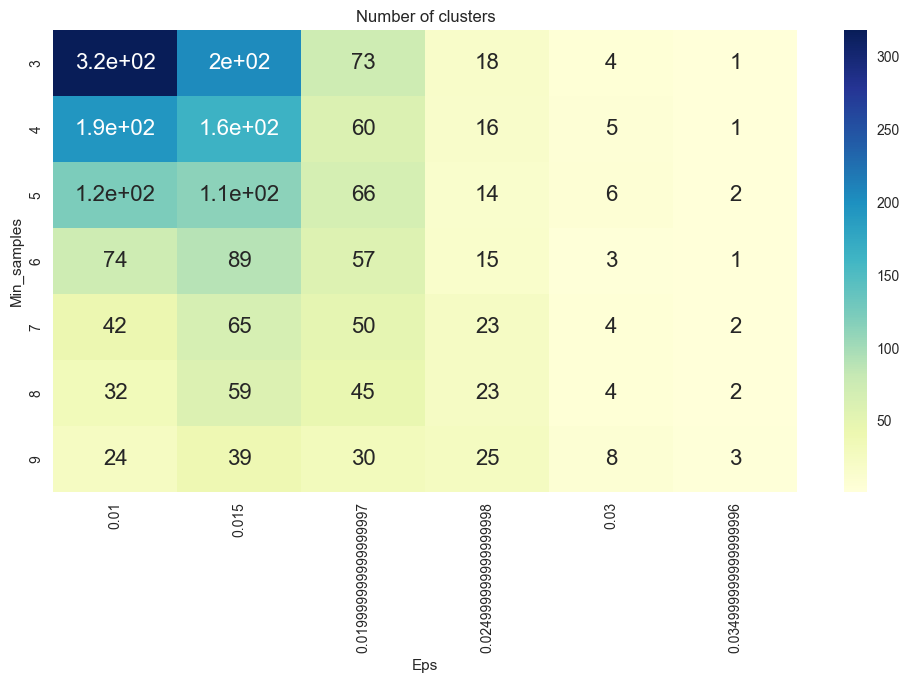

In [166]:
pivot_1 = pd.pivot_table(tmp, values='num_clusters', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pivot_1, annot=True,annot_kws={"size": 16}, cmap="YlGnBu", ax=ax)
ax.set_title('Number of clusters')
plt.show()

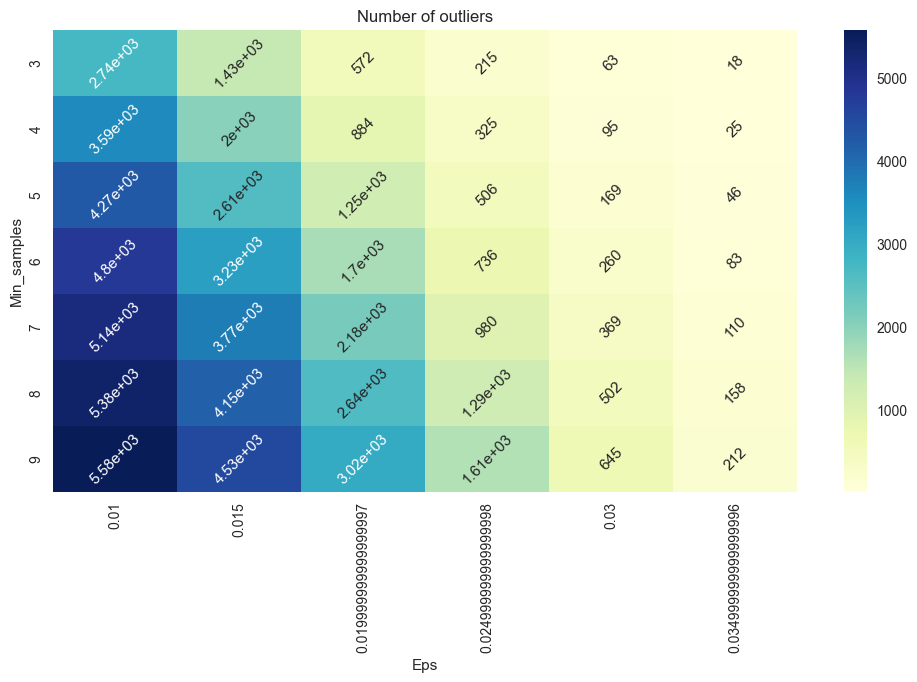

In [167]:
pivot_2 = pd.pivot_table(tmp, values='num_outliers', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pivot_2, annot=True, annot_kws={"size": 11, 'rotation': 45}, cmap="YlGnBu", ax=ax, fmt='.3g')
ax.set_title('Number of outliers')
plt.show()

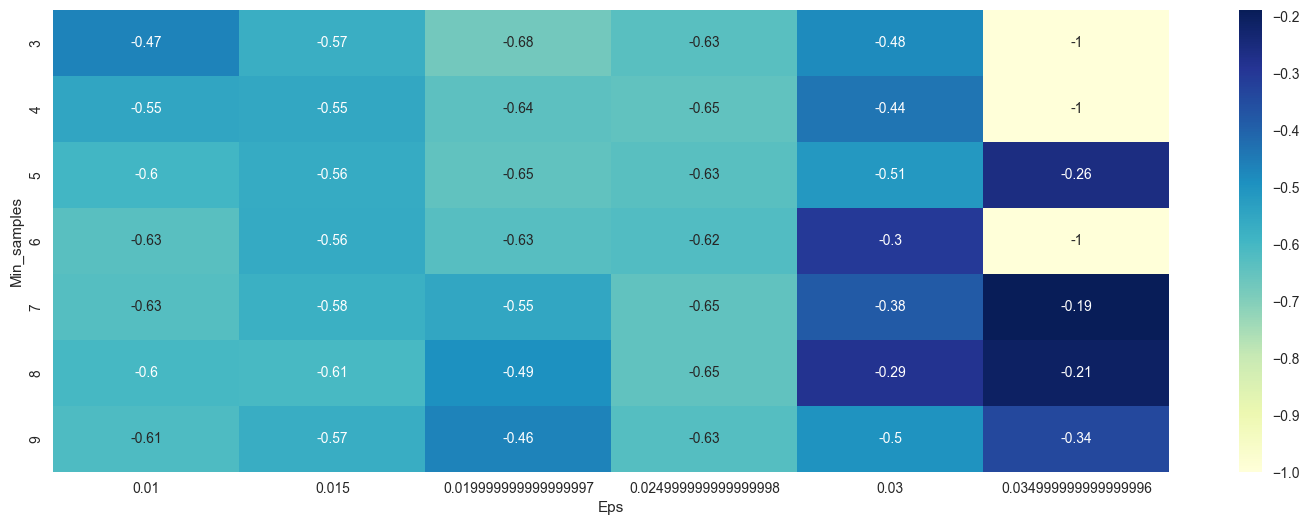

In [168]:
pivot_3 = pd.pivot_table(tmp, values='sil_score', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(18,6))
sns.heatmap(pivot_3, annot=True, annot_kws={"size": 10}, cmap="YlGnBu", ax=ax)
plt.show()

In [169]:
eps, min_samples = DBSCAN_params[np.argmax(sil_score)]
print(f"min_samples: {min_samples}, eps: {eps}")

min_samples: 7, eps: 0.034999999999999996


In [170]:
dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine').fit(X)

df_new['cluster_dbscan'] = dbscan.labels_

df_new.groupby('cluster_dbscan').size()

cluster_dbscan
-1     110
 0    5865
 1       4
dtype: int64

## HDBSCAN

In [171]:
num_clusters = []
num_outliers = []
sil_score = []
# диапазон для поска min_samples/min_cluster_size
params = list(range(3, 50))

for n in params:
    hdbscan = HDBSCAN(min_cluster_size=n, min_samples=n, metric='cosine')
    hdbscan.fit(X)
    num_clusters.append(len(np.unique(hdbscan.labels_[model.labels_>=0])))
    num_outliers.append((hdbscan.labels_==-1).astype(int).sum())
    sil_score.append(silhouette_score(X, hdbscan.labels_, metric='cosine'))

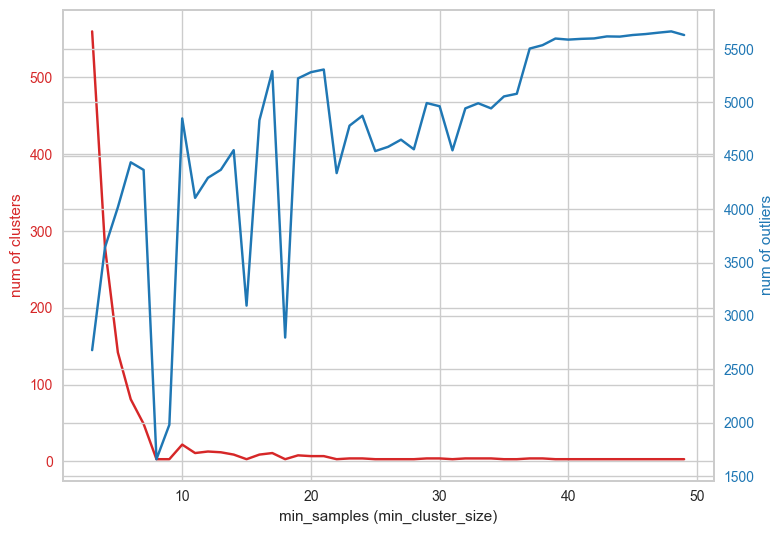

In [172]:
fig, ax1 = plt.subplots()

color='tab:red'
ax1.set_xlabel('min_samples (min_cluster_size)')
ax1.set_ylabel('num of clusters', color='tab:red')
ax1.plot(params, num_clusters, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('num of outliers', color=color)  # we already handled the x-label with ax1
ax2.plot(params, num_outliers, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

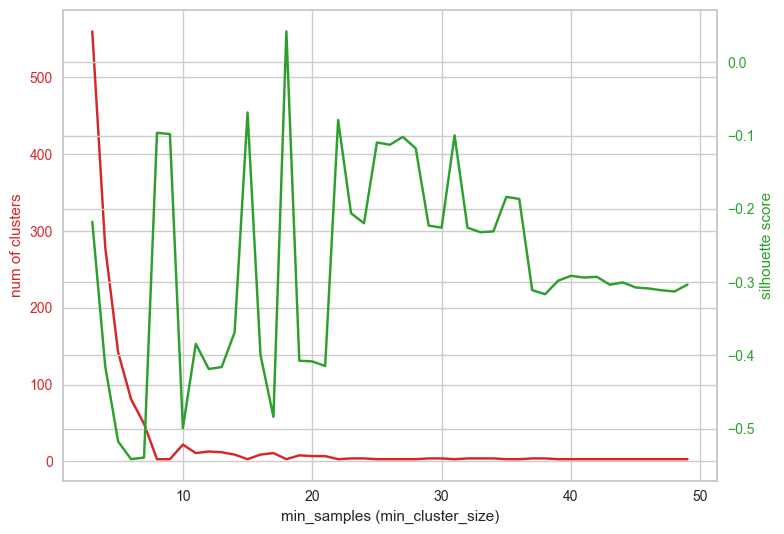

In [173]:
fig, ax1 = plt.subplots()

color='tab:red'
ax1.set_xlabel('min_samples (min_cluster_size)')
ax1.set_ylabel('num of clusters', color='tab:red')
ax1.plot(params, num_clusters, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:green'
ax2.set_ylabel('silhouette score', color=color)  # we already handled the x-label with ax1
ax2.plot(params, sil_score, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [174]:
min_samples = params[np.argmax(sil_score)]
print(f"min_samples (min_cluster_size): {min_samples}")

min_samples (min_cluster_size): 18


In [175]:
hdbscan = HDBSCAN(min_cluster_size=min_samples, min_samples=min_samples, metric='cosine').fit(X)

df_new['cluster_hdbscan'] = hdbscan.labels_

df_new.groupby('cluster_hdbscan').size()

cluster_hdbscan
-1    2798
 0    3163
 1      18
dtype: int64

## OPTICS

In [176]:
num_clusters = []
num_outliers = []
sil_score = []
# диапазон для поска min_samples/min_cluster_size
params = list(range(3, 10))

for n in params:
    optics = OPTICS(min_samples=n, metric='cosine')
    optics.fit(X_norm)
    num_clusters.append(len(np.unique(optics.labels_[model.labels_>=0])))
    num_outliers.append((optics.labels_==-1).astype(int).sum())
    sil_score.append(silhouette_score(X_norm, optics.labels_, metric='cosine'))

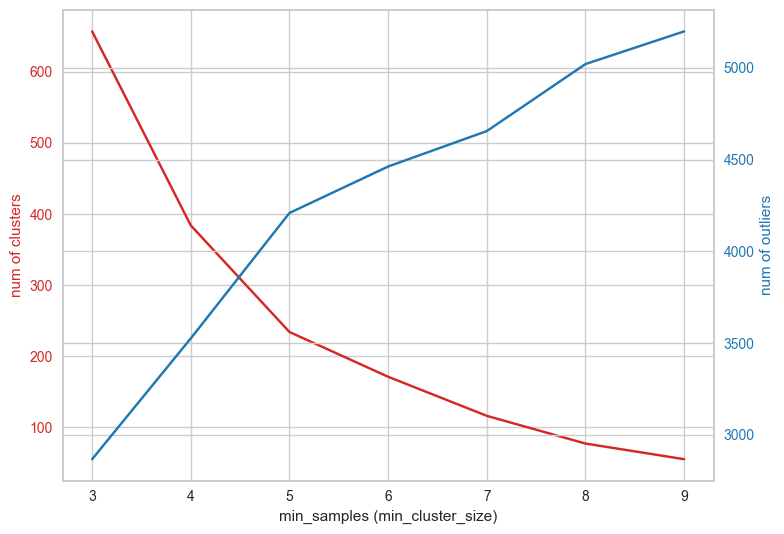

In [177]:
fig, ax1 = plt.subplots()

color='tab:red'
ax1.set_xlabel('min_samples (min_cluster_size)')
ax1.set_ylabel('num of clusters', color='tab:red')
ax1.plot(params, num_clusters, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('num of outliers', color=color)  # we already handled the x-label with ax1
ax2.plot(params, num_outliers, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

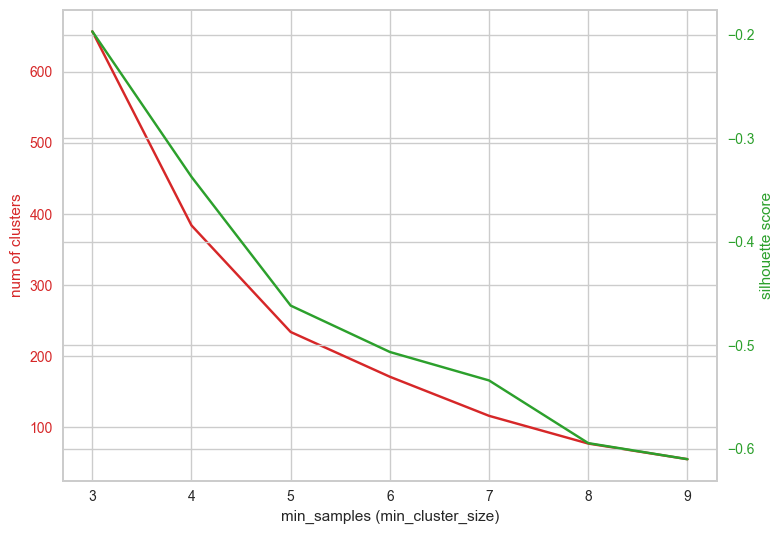

In [178]:
fig, ax1 = plt.subplots()

color='tab:red'
ax1.set_xlabel('min_samples (min_cluster_size)')
ax1.set_ylabel('num of clusters', color='tab:red')
ax1.plot(params, num_clusters, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:green'
ax2.set_ylabel('silhouette score', color=color)  # we already handled the x-label with ax1
ax2.plot(params, sil_score, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [179]:
min_samples = params[np.argmax(sil_score)]
print(f"min_samples (min_cluster_size): {min_samples}")

min_samples (min_cluster_size): 3


In [180]:
optics = OPTICS(min_samples=min_samples, metric='cosine').fit(X_norm)

df_new['cluster_optics'] = optics.labels_

df_new.groupby('cluster_optics').size()

cluster_optics
-1      2868
 0         6
 1         3
 2         4
 3         3
        ... 
 651       3
 652       3
 653       3
 654       3
 655       3
Length: 657, dtype: int64

## Mean-shift

In [197]:
params = np.arange(0.01, 0.1, 0.01)
num_clusters = []
sil_score = []
bandwidths = []

for quantile in params:
    bandwidth = estimate_bandwidth(X_norm, quantile=quantile)
    mean_shift = MeanShift(bandwidth=bandwidth).fit(X_norm)
    bandwidths.append(bandwidth)
    num_clusters.append(len(np.unique(mean_shift.labels_)))
    if len(np.unique(mean_shift.labels_)) == 1:
        sil_score.append(0.0)
    else:
        sil_score.append(silhouette_score(X_norm, mean_shift.labels_, metric='cosine'))

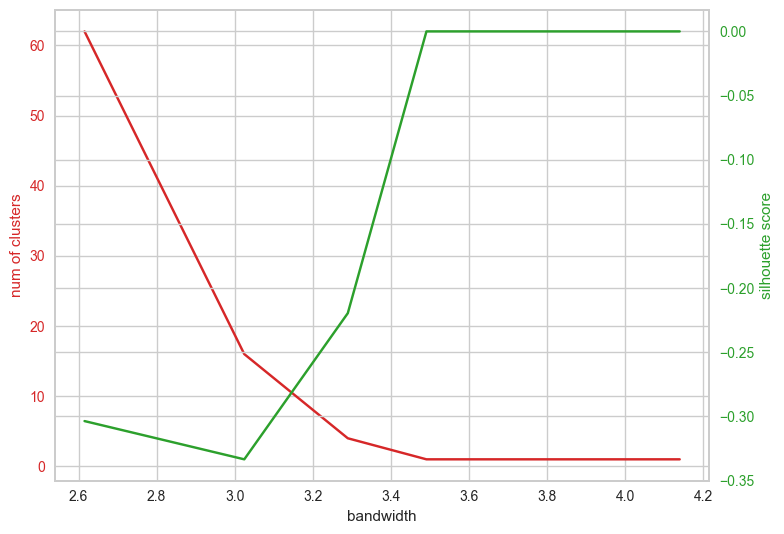

In [198]:
fig, ax1 = plt.subplots()

color='tab:red'
ax1.set_xlabel('bandwidth')
ax1.set_ylabel('num of clusters', color='tab:red')
ax1.plot(bandwidths, num_clusters, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:green'
ax2.set_ylabel('silhouette score', color=color)  # we already handled the x-label with ax1
ax2.plot(bandwidths, sil_score, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [199]:
quantile = params[np.argmax(sil_score)]
bandwidth = bandwidths[np.argmax(sil_score)]
print('quantile: {:.2f}, bandwidth: {:.2f}'.format(quantile, bandwidth))

quantile: 0.04, bandwidth: 3.49


In [ ]:
bandwidth = estimate_bandwidth(X_norm, quantile=quantile)
mean_shift = MeanShift(bandwidth=bandwidth).fit(X_norm)

df_new['cluster_meanshift'] = mean_shift.labels_

df_new.groupby('cluster_meanshift').size()

cluster_meanshift
0    5979
dtype: int64

## Hierarchial

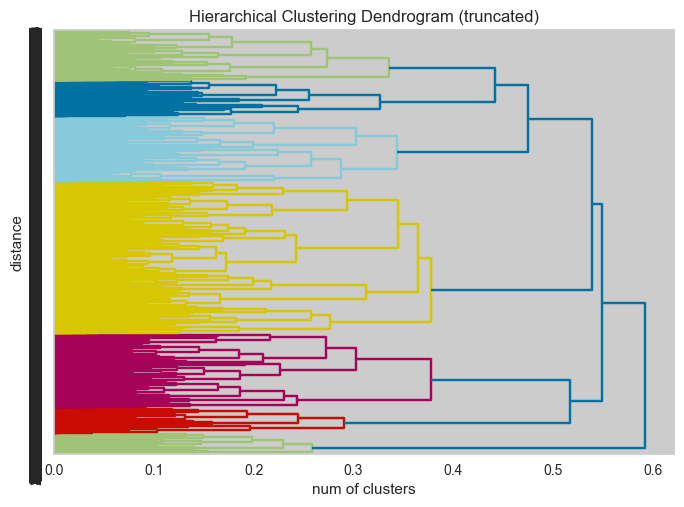

In [185]:
# используем метод Ward, который объединяет по критерию минимальной суммы квадратов расстояний между парами точек двух кластеров
H_cluster = linkage(X_norm, 'average', metric='cosine')

# построим график
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('num of clusters')
plt.ylabel('distance')

dendrogram(
    H_cluster,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True, 
    orientation='right'
)
plt.show()

In [186]:
# переберем значение количества кластеров от 2 до 50
params = list(range(2, 51))
num_clusters = []
sil_score = []

for n_clusters in params:
    aglom_clust = AgglomerativeClustering(n_clusters=n_clusters, linkage='average', metric='cosine').fit(X_norm)
    num_clusters.append(len(np.unique(aglom_clust.labels_)))
    sil_score.append(silhouette_score(X_norm, aglom_clust.labels_, metric='cosine'))

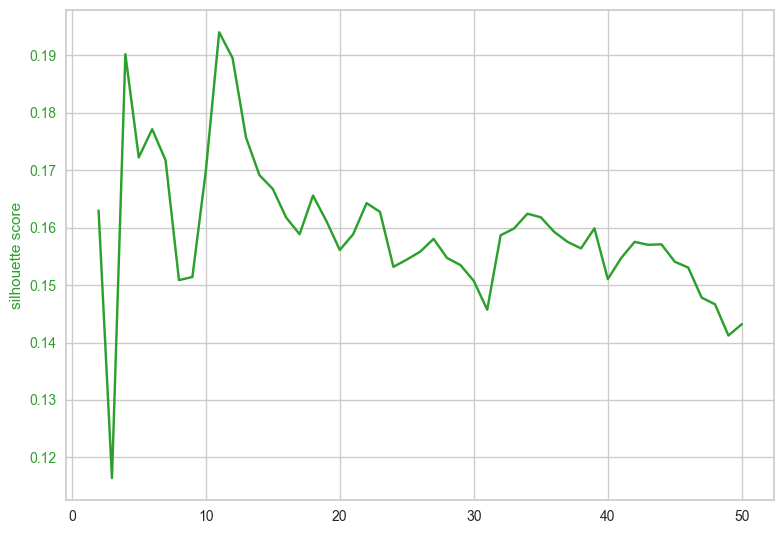

In [187]:
fig, ax1 = plt.subplots()

color = 'tab:green'
ax1.set_ylabel('silhouette score', color=color)  # we already handled the x-label with ax1
ax1.plot(params, sil_score, color=color)
ax1.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [188]:
n_clusters = params[np.argmax(sil_score)]
print(f"n_clusters: {n_clusters}")

n_clusters: 11


In [231]:
n_clusters = 4

In [232]:
aglom_clust = AgglomerativeClustering(n_clusters=n_clusters, linkage='average', metric = 'cosine').fit(X_norm)

df_new['cluster_agglomerative'] = aglom_clust.labels_

df_new.groupby('cluster_agglomerative').size()

cluster_agglomerative
0    1410
1    2146
2    2128
3     295
dtype: int64

## Итоги

In [200]:
algorithms = [
    'cluster_kmeans',
    'cluster_dbscan',
    'cluster_hdbscan',
    'cluster_optics',
    # 'cluster_meanshift',
    'cluster_agglomerative'
]

In [201]:
features = ['sports_sum', 'appearance_sum', 'relationships_sum', 'music_sum', 'religion_sum', 'fashion_sum', 'dark_sum'] 

In [228]:
overview = []
for algo in algorithms:
    n_clusters = df_new[df_new[algo]>=0][algo].drop_duplicates().shape[0]
    n_outliers = df_new[df_new[algo]==-1].shape[0]
    sil_score = silhouette_score(df_new[features], df_new[algo], metric='cosine')
    sizes = df_new[df_new[algo]>=-1].groupby(algo).size().to_frame('size').reset_index()
    min_size = sizes['size'].min()
    max_size = sizes['size'].max()
    avg_size = round(sizes['size'].mean())
    overview.append((algo[8:], n_clusters, n_outliers, sil_score, min_size, max_size, avg_size))
overview = pd.DataFrame(overview, columns=[
    'алгоритм', 'количество кластеров', 'количество выбросов', 'silhouette score',
    'минимальный размер кластера', 'максимальный размер кластера', 'средний размер кластера'
])
overview.head(len(algorithms))

,алгоритм,количество кластеров,количество выбросов,silhouette score,минимальный размер кластера,максимальный размер кластера,средний размер кластера
0,kmeans,3,0,0.069002,1225,2942,1993
1,dbscan,2,110,-0.188851,4,5865,1993
2,hdbscan,2,2798,0.042335,18,3163,1993
3,optics,656,2868,-0.196625,3,2868,9
4,agglomerative,11,0,0.194038,295,920,544


In [229]:
for i in range(3):
    print(f"Кластер {i}")
    print(df_new[df_new['cluster_kmeans']==i][features].describe())
    print()

Кластер 0
        sports_sum  appearance_sum  relationships_sum    music_sum  \
count  2942.000000     2942.000000        2942.000000  2942.000000   
mean      1.644897        1.359959           0.999320     1.608478   
std       1.605974        1.348719           1.449439     1.479303   
min       0.000000        0.000000           0.000000     0.000000   
25%       0.000000        0.000000           0.000000     0.714286   
50%       1.428571        1.000000           0.000000     1.428571   
75%       2.857143        2.000000           1.666667     2.142857   
max       5.000000        5.000000           5.000000     5.000000   

       religion_sum  fashion_sum     dark_sum  
count   2942.000000  2942.000000  2942.000000  
mean       1.466264     1.683804     0.001700  
std        1.664193     1.611932     0.065172  
min        0.000000     0.000000     0.000000  
25%        0.000000     0.000000     0.000000  
50%        1.250000     1.250000     0.000000  
75%        2.500000    

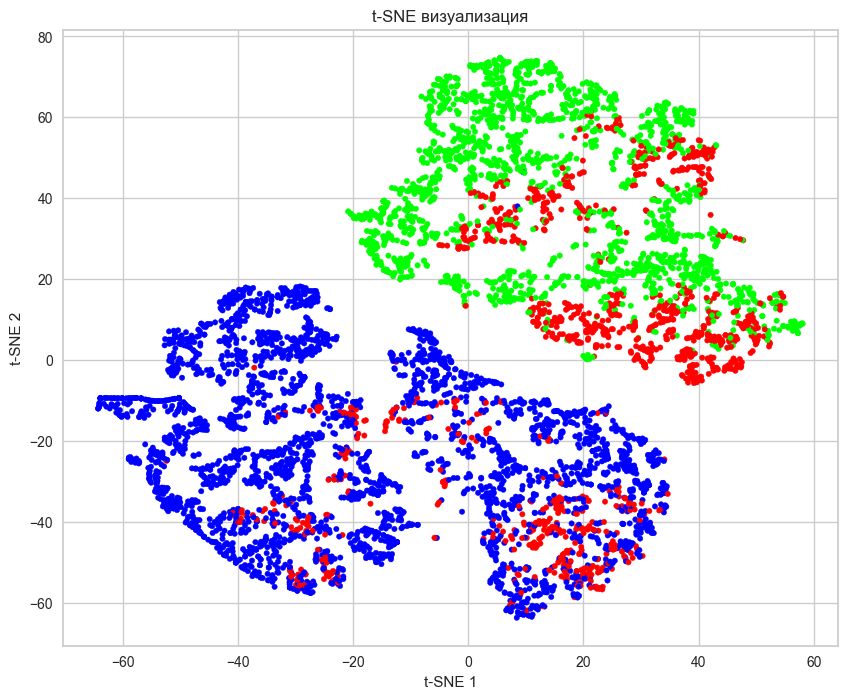

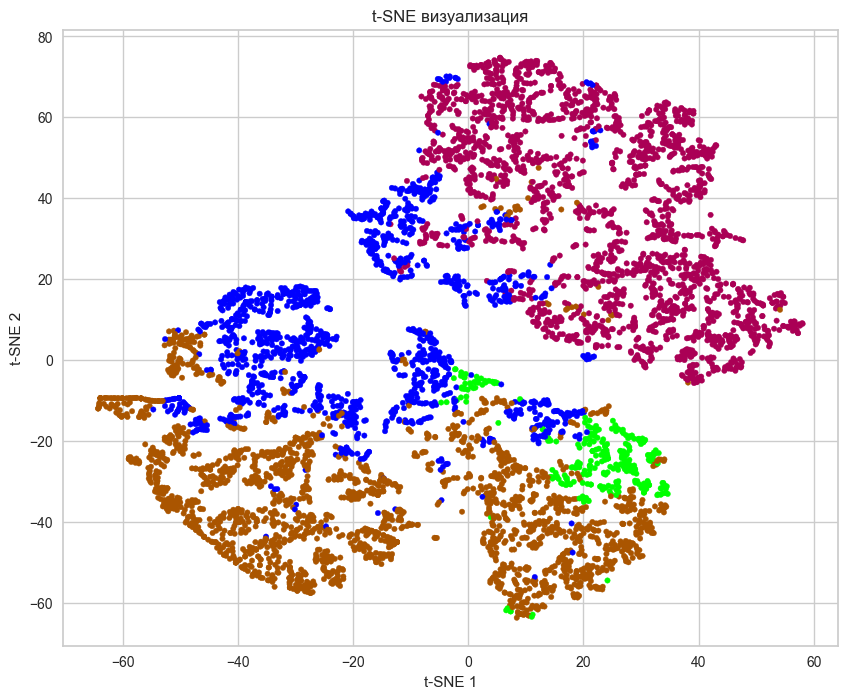

In [235]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


def apply_tsne(X, n_components=2, perplexity=30, random_state=42):
    """
    Применяет t-SNE к данным и возвращает результат
    
    Параметры:
    X - входные данные (n_samples, n_features)
    n_components - размерность выходного пространства (2 или 3)
    perplexity - параметр перплексии
    random_state - для воспроизводимости
    
    Возвращает:
    tsne_results - координаты в пространстве t-SNE
    """
    
    # Инициализация и применение t-SNE
    tsne = TSNE(n_components=n_components,
                perplexity=perplexity,
                random_state=random_state,
                n_iter=1000,
                learning_rate='auto',
                init='pca',
                metric='cosine')
    
    tsne_results = tsne.fit_transform(X)
    
    return tsne_results

def plot_tsne(tsne_results, labels=None):
    """
    Визуализирует результаты t-SNE
    
    Параметры:
    tsne_results - координаты из t-SNE
    labels - метки кластеров (если есть)
    """
    plt.figure(figsize=(10, 8))
    
    if labels is None:
        plt.scatter(tsne_results[:, 0], tsne_results[:, 1],
                   alpha=0.6, s=10)
    else:
        plt.scatter(tsne_results[:,0], tsne_results[:,1], c=labels, cmap="brg", s=15)
        
        plt.legend()
    
    plt.title('t-SNE визуализация')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.show()



tsne_results = apply_tsne(df_new[features])

# Визуализация
plot_tsne(tsne_results, df_new['cluster_kmeans'])

plot_tsne(tsne_results, df_new['cluster_agglomerative'])
